In [37]:
import numpy as np
import networkx as nx
from rdkit import Chem
import matplotlib.pyplot as plt
from typing import List
from karateclub.estimator import Estimator
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from karateclub.utils.treefeatures import WeisfeilerLehmanHashing

In [66]:
print('Loading NCI1 dataset')

graphs = []
y = []

filepath = "datasets/NCI_full/1total-connect.sdf"

supplier = Chem.SDMolSupplier(filepath, sanitize=False, removeHs=False)
for mol in supplier:
    if mol is None:
        continue

    G = nx.Graph()

    # Add atoms as nodes
    for atom in mol.GetAtoms():
        G.add_node(
            atom.GetIdx(),
            feature=atom.GetSymbol()   # WL uses node labels
        )

    for bond in mol.GetBonds():
        G.add_edge(
            bond.GetBeginAtomIdx(),
            bond.GetEndAtomIdx(),
            bond_type=str(bond.GetBondType()),
            bond_order=bond.GetBondTypeAsDouble(),
            aromatic=bond.GetIsAromatic(),
            in_ring=bond.IsInRing(),
            conjugated=bond.GetIsConjugated(),
            stereo=str(bond.GetStereo())
        )

    # Get graph label
    # In NCI1, class label is stored as a molecule property
    label = int(float(mol.GetProp("value")))
    graphs.append(G)


    y.append(label)

print(f"Loaded {len(graphs)} graphs")

Loading NCI1 dataset


[15:17:38] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.
[15:17:41] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.
[15:17:46] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.
[15:17:49] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.
[15:17:54] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.
[15:17:54] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.


Loaded 37349 graphs


In [114]:
graph = graphs[0]

In [115]:
graph.nodes()

NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43))

In [116]:
graph.number_of_edges()

47

In [117]:
graph.number_of_nodes()

44

In [118]:
graph.edges()

EdgeView([(0, 29), (1, 12), (1, 13), (2, 15), (2, 25), (3, 16), (3, 21), (4, 17), (5, 22), (5, 36), (6, 21), (7, 24), (8, 25), (9, 31), (9, 43), (10, 17), (10, 21), (11, 24), (11, 27), (11, 34), (12, 13), (12, 15), (12, 18), (13, 14), (14, 16), (14, 23), (15, 20), (16, 19), (17, 19), (17, 22), (20, 24), (22, 26), (25, 28), (26, 33), (27, 29), (27, 30), (28, 40), (28, 41), (29, 31), (30, 32), (31, 35), (32, 35), (32, 37), (33, 38), (37, 39), (38, 39), (39, 42)])

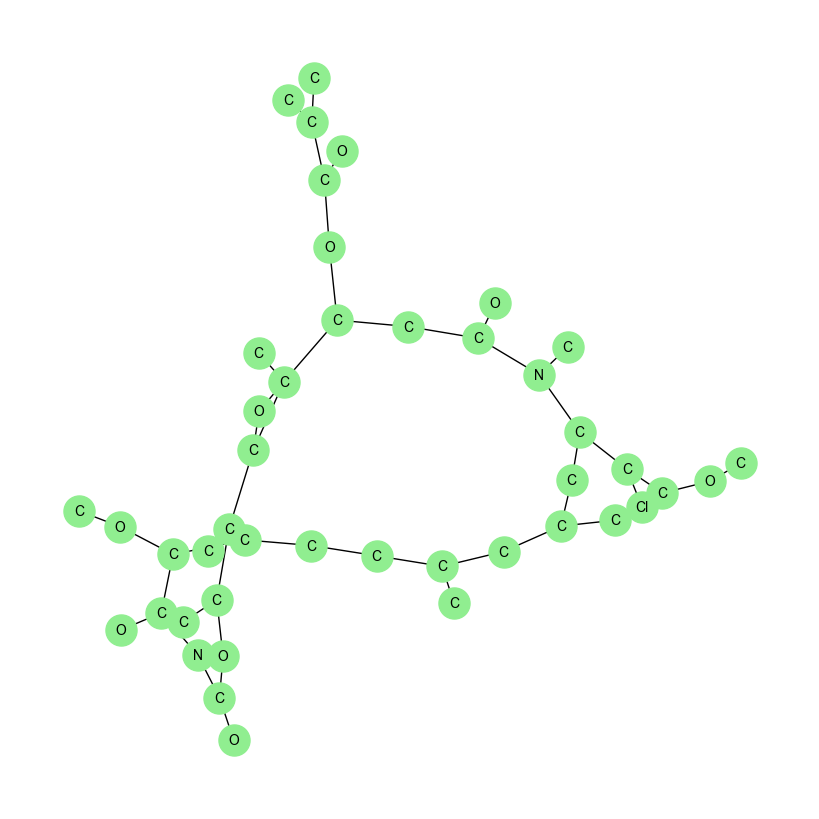

In [119]:
plt.figure(figsize=(8, 8))

pos = nx.spring_layout(graph)

nx.draw(
    graph,
    pos,
    with_labels=True,
    labels=nx.get_node_attributes(graph, "feature"),
    node_color="lightgreen",
    node_size=500,
    font_size=10
)

plt.show()

In [120]:
l_graph = nx.line_graph(graph)

In [121]:
l_graph.nodes()

NodeView(((0, 29), (4, 17), (6, 21), (7, 24), (8, 25), (12, 18), (14, 23), (11, 34), (5, 36), (28, 40), (28, 41), (39, 42), (9, 43), (20, 24), (11, 24), (17, 19), (17, 22), (1, 13), (13, 14), (15, 20), (5, 22), (10, 17), (3, 21), (10, 21), (12, 15), (9, 31), (1, 12), (2, 15), (29, 31), (12, 13), (31, 35), (32, 35), (37, 39), (33, 38), (38, 39), (14, 16), (11, 27), (27, 29), (3, 16), (32, 37), (22, 26), (2, 25), (25, 28), (30, 32), (27, 30), (26, 33), (16, 19)))

In [122]:
node_mapper = {node: i for i, node in enumerate(l_graph.nodes())}

In [123]:
node_mapper

{(0, 29): 0,
 (4, 17): 1,
 (6, 21): 2,
 (7, 24): 3,
 (8, 25): 4,
 (12, 18): 5,
 (14, 23): 6,
 (11, 34): 7,
 (5, 36): 8,
 (28, 40): 9,
 (28, 41): 10,
 (39, 42): 11,
 (9, 43): 12,
 (20, 24): 13,
 (11, 24): 14,
 (17, 19): 15,
 (17, 22): 16,
 (1, 13): 17,
 (13, 14): 18,
 (15, 20): 19,
 (5, 22): 20,
 (10, 17): 21,
 (3, 21): 22,
 (10, 21): 23,
 (12, 15): 24,
 (9, 31): 25,
 (1, 12): 26,
 (2, 15): 27,
 (29, 31): 28,
 (12, 13): 29,
 (31, 35): 30,
 (32, 35): 31,
 (37, 39): 32,
 (33, 38): 33,
 (38, 39): 34,
 (14, 16): 35,
 (11, 27): 36,
 (27, 29): 37,
 (3, 16): 38,
 (32, 37): 39,
 (22, 26): 40,
 (2, 25): 41,
 (25, 28): 42,
 (30, 32): 43,
 (27, 30): 44,
 (26, 33): 45,
 (16, 19): 46}

In [124]:
l_graph.edges()

EdgeView([((0, 29), (29, 31)), ((0, 29), (27, 29)), ((4, 17), (17, 22)), ((4, 17), (10, 17)), ((4, 17), (17, 19)), ((6, 21), (3, 21)), ((6, 21), (10, 21)), ((7, 24), (20, 24)), ((7, 24), (11, 24)), ((8, 25), (2, 25)), ((8, 25), (25, 28)), ((12, 18), (12, 15)), ((12, 18), (12, 13)), ((12, 18), (1, 12)), ((14, 23), (14, 16)), ((14, 23), (13, 14)), ((11, 34), (11, 24)), ((11, 34), (11, 27)), ((5, 36), (5, 22)), ((28, 40), (28, 41)), ((28, 40), (25, 28)), ((28, 41), (25, 28)), ((39, 42), (37, 39)), ((39, 42), (38, 39)), ((9, 43), (9, 31)), ((20, 24), (15, 20)), ((20, 24), (11, 24)), ((11, 24), (11, 27)), ((17, 19), (17, 22)), ((17, 19), (10, 17)), ((17, 19), (16, 19)), ((17, 22), (5, 22)), ((17, 22), (10, 17)), ((17, 22), (22, 26)), ((1, 13), (13, 14)), ((1, 13), (1, 12)), ((1, 13), (12, 13)), ((13, 14), (12, 13)), ((13, 14), (14, 16)), ((15, 20), (2, 15)), ((15, 20), (12, 15)), ((5, 22), (22, 26)), ((10, 17), (10, 21)), ((3, 21), (10, 21)), ((3, 21), (3, 16)), ((12, 15), (2, 15)), ((12, 1

In [125]:
edges = [[node_mapper[edge[0]], node_mapper[edge[1]]] for edge in l_graph.edges()]

In [126]:
edges

[[0, 28],
 [0, 37],
 [1, 16],
 [1, 21],
 [1, 15],
 [2, 22],
 [2, 23],
 [3, 13],
 [3, 14],
 [4, 41],
 [4, 42],
 [5, 24],
 [5, 29],
 [5, 26],
 [6, 35],
 [6, 18],
 [7, 14],
 [7, 36],
 [8, 20],
 [9, 10],
 [9, 42],
 [10, 42],
 [11, 32],
 [11, 34],
 [12, 25],
 [13, 19],
 [13, 14],
 [14, 36],
 [15, 16],
 [15, 21],
 [15, 46],
 [16, 20],
 [16, 21],
 [16, 40],
 [17, 18],
 [17, 26],
 [17, 29],
 [18, 29],
 [18, 35],
 [19, 27],
 [19, 24],
 [20, 40],
 [21, 23],
 [22, 23],
 [22, 38],
 [24, 27],
 [24, 29],
 [24, 26],
 [25, 28],
 [25, 30],
 [26, 29],
 [27, 41],
 [28, 30],
 [28, 37],
 [30, 31],
 [31, 39],
 [31, 43],
 [32, 39],
 [32, 34],
 [33, 34],
 [33, 45],
 [35, 46],
 [35, 38],
 [36, 37],
 [36, 44],
 [37, 44],
 [38, 46],
 [39, 43],
 [40, 45],
 [41, 42],
 [43, 44]]

In [127]:
line_graph = nx.from_edgelist(edges)

In [128]:
line_graph.nodes

NodeView((0, 28, 37, 1, 16, 21, 15, 2, 22, 23, 3, 13, 14, 4, 41, 42, 5, 24, 29, 26, 6, 35, 18, 7, 36, 8, 20, 9, 10, 11, 32, 34, 12, 25, 19, 46, 40, 17, 27, 38, 30, 31, 39, 43, 33, 45, 44))

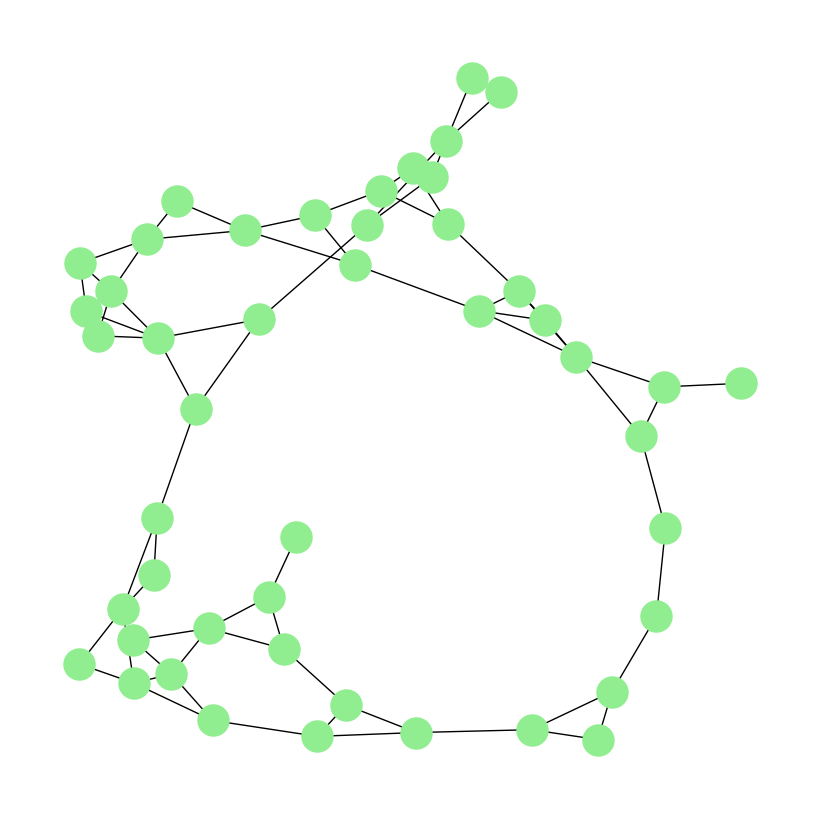

In [81]:
plt.figure(figsize=(8, 8))

pos = nx.spring_layout(line_graph)

nx.draw(
    line_graph,
    pos,
    with_labels=True,
    labels=nx.get_node_attributes(line_graph, "feature"),
    node_color="lightgreen",
    node_size=500,
    font_size=10
)

plt.show()

In [82]:
for _, _, data in line_graph.edges(data=True):
    print(data)

{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}


In [83]:
line_graph.number_of_nodes()

47

In [84]:
line_graph.number_of_edges()

71

In [85]:
line_graph.nodes(data=True)

NodeDataView({0: {}, 28: {}, 37: {}, 1: {}, 16: {}, 21: {}, 15: {}, 2: {}, 22: {}, 23: {}, 3: {}, 13: {}, 14: {}, 4: {}, 41: {}, 42: {}, 5: {}, 24: {}, 29: {}, 26: {}, 6: {}, 35: {}, 18: {}, 7: {}, 36: {}, 8: {}, 20: {}, 9: {}, 10: {}, 11: {}, 32: {}, 34: {}, 12: {}, 25: {}, 19: {}, 46: {}, 40: {}, 17: {}, 27: {}, 38: {}, 30: {}, 31: {}, 39: {}, 43: {}, 33: {}, 45: {}, 44: {}})

from nx docs

In [166]:
g = graphs[0]

In [167]:
print(f"nodes {g.number_of_nodes()}, edges {g.number_of_edges()}")

nodes 44, edges 47


In [168]:
g.edges(data=True)

EdgeDataView([(0, 29, {'bond_type': 'SINGLE', 'bond_order': 1.0, 'aromatic': False, 'in_ring': False, 'conjugated': False, 'stereo': 'STEREONONE'}), (1, 12, {'bond_type': 'SINGLE', 'bond_order': 1.0, 'aromatic': False, 'in_ring': True, 'conjugated': False, 'stereo': 'STEREONONE'}), (1, 13, {'bond_type': 'SINGLE', 'bond_order': 1.0, 'aromatic': False, 'in_ring': True, 'conjugated': False, 'stereo': 'STEREONONE'}), (2, 15, {'bond_type': 'SINGLE', 'bond_order': 1.0, 'aromatic': False, 'in_ring': False, 'conjugated': False, 'stereo': 'STEREONONE'}), (2, 25, {'bond_type': 'SINGLE', 'bond_order': 1.0, 'aromatic': False, 'in_ring': False, 'conjugated': False, 'stereo': 'STEREONONE'}), (3, 16, {'bond_type': 'SINGLE', 'bond_order': 1.0, 'aromatic': False, 'in_ring': True, 'conjugated': False, 'stereo': 'STEREONONE'}), (3, 21, {'bond_type': 'SINGLE', 'bond_order': 1.0, 'aromatic': False, 'in_ring': True, 'conjugated': False, 'stereo': 'STEREONONE'}), (4, 17, {'bond_type': 'SINGLE', 'bond_order':

In [169]:
H = nx.line_graph(g)

In [170]:
H.number_of_nodes()

47

In [171]:
H.nodes(data=True)

NodeDataView({(0, 29): {}, (4, 17): {}, (6, 21): {}, (7, 24): {}, (8, 25): {}, (12, 18): {}, (14, 23): {}, (11, 34): {}, (5, 36): {}, (28, 40): {}, (28, 41): {}, (39, 42): {}, (9, 43): {}, (20, 24): {}, (11, 24): {}, (17, 19): {}, (17, 22): {}, (1, 13): {}, (13, 14): {}, (15, 20): {}, (5, 22): {}, (10, 17): {}, (3, 21): {}, (10, 21): {}, (12, 15): {}, (9, 31): {}, (1, 12): {}, (2, 15): {}, (29, 31): {}, (12, 13): {}, (31, 35): {}, (32, 35): {}, (37, 39): {}, (33, 38): {}, (38, 39): {}, (14, 16): {}, (11, 27): {}, (27, 29): {}, (3, 16): {}, (32, 37): {}, (22, 26): {}, (2, 25): {}, (25, 28): {}, (30, 32): {}, (27, 30): {}, (26, 33): {}, (16, 19): {}})

In [172]:
H.add_nodes_from((node, g.edges[node]) for node in H)

In [173]:
H.nodes(data=True)

NodeDataView({(0, 29): {'bond_type': 'SINGLE', 'bond_order': 1.0, 'aromatic': False, 'in_ring': False, 'conjugated': False, 'stereo': 'STEREONONE'}, (4, 17): {'bond_type': 'SINGLE', 'bond_order': 1.0, 'aromatic': False, 'in_ring': False, 'conjugated': False, 'stereo': 'STEREONONE'}, (6, 21): {'bond_type': 'DOUBLE', 'bond_order': 2.0, 'aromatic': False, 'in_ring': False, 'conjugated': False, 'stereo': 'STEREONONE'}, (7, 24): {'bond_type': 'DOUBLE', 'bond_order': 2.0, 'aromatic': False, 'in_ring': False, 'conjugated': False, 'stereo': 'STEREONONE'}, (8, 25): {'bond_type': 'DOUBLE', 'bond_order': 2.0, 'aromatic': False, 'in_ring': False, 'conjugated': False, 'stereo': 'STEREONONE'}, (12, 18): {'bond_type': 'SINGLE', 'bond_order': 1.0, 'aromatic': False, 'in_ring': False, 'conjugated': False, 'stereo': 'STEREONONE'}, (14, 23): {'bond_type': 'SINGLE', 'bond_order': 1.0, 'aromatic': False, 'in_ring': False, 'conjugated': False, 'stereo': 'STEREONONE'}, (11, 34): {'bond_type': 'SINGLE', 'bond

In [110]:
H.number_of_nodes()

47

In [203]:
graph = graphs[0]

In [204]:
# graph.edges(data=True)

In [205]:
l_graph = nx.line_graph(graph)

In [206]:
# l_graph.nodes(data=True)

In [207]:
# l_graph.edges

In [208]:
l_graph.add_nodes_from((node, graph.edges[node]) for node in l_graph)

In [209]:
# l_graph.nodes(data=True)

In [210]:
node_mapper = {node: i for i, node in enumerate(l_graph.nodes())}

In [211]:
# node_mapper

In [212]:
# l_graph.edges(data=True)

In [213]:
edges = [[node_mapper[edge[0]], node_mapper[edge[1]]] for edge in l_graph.edges()]

In [214]:
# edges

In [215]:
line_graph = nx.from_edgelist(edges)

In [216]:
# line_graph.nodes(data=True)

In [217]:
# l_graph.nodes(data=True)

In [218]:
# dict(l_graph.nodes())[(0, 29)]

In [219]:
line_graph.add_nodes_from((node_mapper[node], dict(l_graph.nodes())[node]) for node in node_mapper)

In [221]:
# line_graph.nodes(data=True)

In [ ]:
    def create_line_graphs(self, graphs):
        line_graphs = []
        for graph in graphs:
            h = nx.line_graph(graph)
            node_mapper = {node: i for i, node in enumerate(h.nodes())}
            edges = [[node_mapper[edge[0]], node_mapper[edge[1]]] for edge in h.edges()]
            h = nx.from_edgelist(edges)
            h.add_nodes_from((node, graph.edges[node]) for node in h)
            line_graphs.append(h)
        return line_graphs

In [225]:
def create_line_graphs(graph):
    l_graph = nx.line_graph(graph)
    l_graph.add_nodes_from((node, graph.edges[node]) for node in l_graph)
    node_mapper = {node: i for i, node in enumerate(l_graph.nodes())}
    edges = [[node_mapper[edge[0]], node_mapper[edge[1]]] for edge in l_graph.edges()]
    line_graph = nx.from_edgelist(edges)
    line_graph.add_nodes_from((node_mapper[node], dict(l_graph.nodes())[node]) for node in node_mapper)
    return line_graph

In [226]:
line_g = create_line_graphs(graphs[0])

In [227]:
line_g.nodes(data=True)

NodeDataView({0: {'bond_type': 'SINGLE', 'bond_order': 1.0, 'aromatic': False, 'in_ring': False, 'conjugated': False, 'stereo': 'STEREONONE'}, 28: {'bond_type': 'SINGLE', 'bond_order': 1.0, 'aromatic': False, 'in_ring': True, 'conjugated': False, 'stereo': 'STEREONONE'}, 37: {'bond_type': 'DOUBLE', 'bond_order': 2.0, 'aromatic': False, 'in_ring': True, 'conjugated': False, 'stereo': 'STEREONONE'}, 1: {'bond_type': 'SINGLE', 'bond_order': 1.0, 'aromatic': False, 'in_ring': False, 'conjugated': False, 'stereo': 'STEREONONE'}, 16: {'bond_type': 'SINGLE', 'bond_order': 1.0, 'aromatic': False, 'in_ring': True, 'conjugated': False, 'stereo': 'STEREONONE'}, 21: {'bond_type': 'SINGLE', 'bond_order': 1.0, 'aromatic': False, 'in_ring': True, 'conjugated': False, 'stereo': 'STEREONONE'}, 15: {'bond_type': 'SINGLE', 'bond_order': 1.0, 'aromatic': False, 'in_ring': True, 'conjugated': False, 'stereo': 'STEREONONE'}, 2: {'bond_type': 'DOUBLE', 'bond_order': 2.0, 'aromatic': False, 'in_ring': False, 